All Residuals:
X = 0.00, Residual = 0.5809
X = 0.01, Residual = 0.3941
X = 0.02, Residual = 0.9812
X = 0.03, Residual = 0.4223
X = 0.04, Residual = -0.7140
X = 0.05, Residual = -0.5904
X = 0.06, Residual = -0.7542
X = 0.07, Residual = 0.3696
X = 0.08, Residual = -0.0496
X = 0.09, Residual = 0.9795
X = 0.10, Residual = -0.3748
X = 0.11, Residual = -0.0526
X = 0.12, Residual = -0.7453
X = 0.13, Residual = -0.1082
X = 0.14, Residual = -0.9863
X = 0.15, Residual = -0.5676
X = 0.16, Residual = -0.5197
X = 0.17, Residual = 0.9681
X = 0.18, Residual = 0.9777
X = 0.19, Residual = 0.7434
X = 0.20, Residual = -0.4067
X = 0.21, Residual = -0.7705
X = 0.22, Residual = -0.8191
X = 0.23, Residual = -0.9298
X = 0.24, Residual = 0.4022
X = 0.25, Residual = 0.8484
X = 0.26, Residual = -0.4280
X = 0.27, Residual = -0.1282
X = 0.28, Residual = 0.7161
X = 0.29, Residual = -0.6754
X = 0.30, Residual = -0.3687
X = 0.31, Residual = -0.9235
X = 0.32, Residual = -0.7243
X = 0.33, Residual = 0.8216
X = 0.34, Re

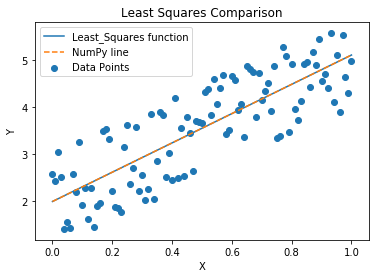

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def Least_Squares(X,Y):
    m = (X.size*np.sum(X*Y)-np.sum(X)*np.sum(Y))/(X.size*np.sum(X**2)-(np.sum(X)**2))
    b = (np.sum(Y) - m*np.sum(X))/(X.size)
    return m, b

# true line
m_true = 3
b_true = 2

X = np.arange(0,1.01,0.01)

noise = np.random.uniform(-1,1,X.size)

Y = m_true*X + b_true + noise

sort_idx = np.argsort(X)
X = X[sort_idx]
Y = Y[sort_idx]


m_custom, b_custom = Least_Squares(X,Y)

A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A,Y,rcond=None)[0]

Y_pred = m_custom*X + b_custom

residuals = Y - Y_pred

print("All Residuals:")
for i in range(len(residuals)):
    print(f"X = {X[i]:.2f}, Residual = {residuals[i]:.4f}")


max_residual = np.max(residuals)
min_residual = np.min(residuals)
max_index = np.argmax(residuals)
min_index = np.argmin(residuals)

print("\nTrue Line:")
print("m =", m_true, "b =", b_true)
print("\nCustom Least Squares:")
print("m =", m_custom, "b =", b_custom)
print("\nNumPy Least Squares:")
print("m =", m_np, "b =", b_np)
print("\nLargest Residual:", max_residual, "at X =", X[max_index])
print("Smallest Residual:", min_residual, "at X =", X[min_index])


plt.scatter(X,Y,label="Data Points")
x_line = np.linspace(0,1,100)
plt.plot(x_line, m_custom*x_line + b_custom,label="Least_Squares function")
plt.plot(x_line, m_np*x_line + b_np,'--',label="NumPy line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Comparison")
plt.legend()
plt.show()